In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:

def generate_gbm_paths(S0, mu, sigma, T, N, M, mesh_size=1e-3):
    dt = mesh_size
    num_steps = int(T / dt)
    paths = np.zeros((M, num_steps + 1))
    paths[:, 0] = S0
    for i in range(1, num_steps + 1):
        Z = np.random.standard_normal(M)
        paths[:, i] = paths[:, i - 1] + paths[:, i - 1] * mu * dt + paths[:, i - 1] * sigma * np.sqrt(dt) * Z
    # Only return exactly N time steps spaced out evenly over the interval [0, T]
    step_indices = np.linspace(0, num_steps, N + 1, dtype=int)
    return paths[:, step_indices]

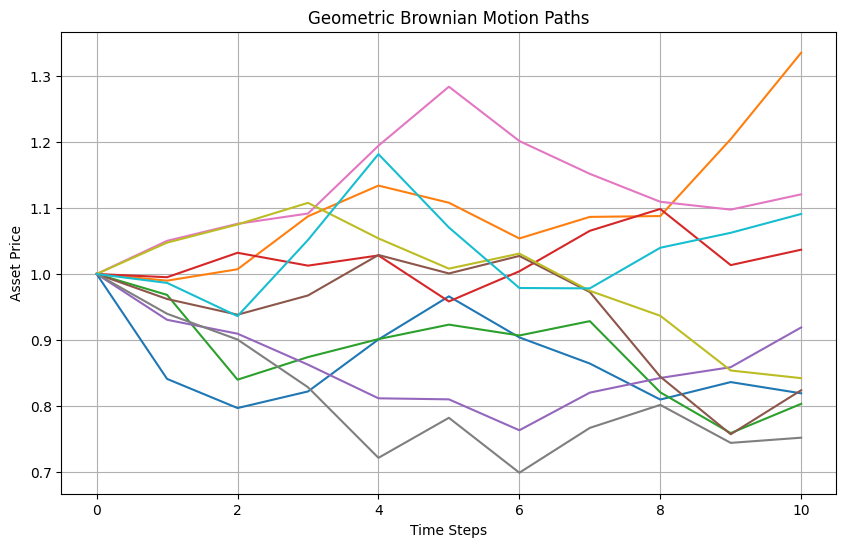

In [23]:
paths = generate_gbm_paths(S0=1, mu=0.1, sigma=0.2, T=1, N=10, M=10)
# Plot the paths
plt.figure(figsize=(10, 6))
for i in range(paths.shape[0]):
    plt.plot(paths[i], label=f'Path {i+1}')
plt.title('Geometric Brownian Motion Paths')
plt.xlabel('Time Steps')
plt.ylabel('Asset Price')
plt.grid()
plt.show()

In [25]:
def path_wise_gbm_parameter_estimation(paths, T):
    N = paths.shape[1] - 1  # Number of time steps
    dt = T / N
    mu_estimates = []
    sigma_estimates = []
    
    for path in paths:
        log_returns = np.diff(np.log(path))
        mu_hat = np.mean(log_returns) / dt + (np.var(log_returns) / (2 * dt))
        sigma_hat = np.sqrt(np.var(log_returns) / dt)
        mu_estimates.append(mu_hat)
        sigma_estimates.append(sigma_hat)
    
    return np.array(mu_estimates), np.array(sigma_estimates)

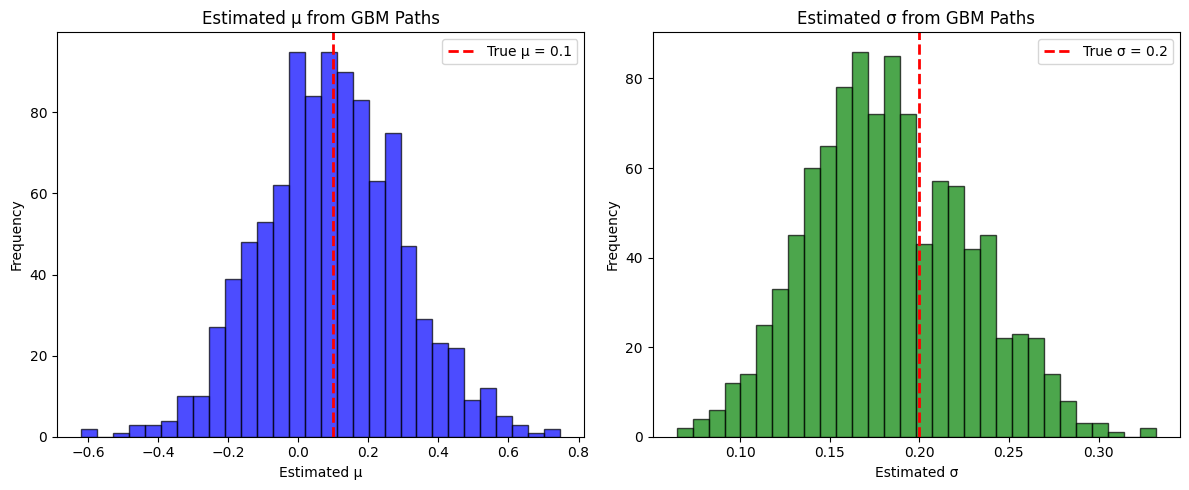

In [27]:
true_mu = 0.1
true_sigma = 0.2
paths = generate_gbm_paths(S0=1, mu=true_mu, sigma=true_sigma, T=1, N=10, M=1000, mesh_size=1e-3)
estimated_mu, estimated_sigma = path_wise_gbm_parameter_estimation(paths, T=1)
# Plot the histogram of estimated parameters and mark the true values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(estimated_mu, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(true_mu, color='red', linestyle='dashed', linewidth=2, label=f'True μ = {true_mu}')
plt.title('Estimated μ from GBM Paths')
plt.xlabel('Estimated μ')
plt.ylabel('Frequency')
plt.legend()
plt.subplot(1, 2, 2)
plt.hist(estimated_sigma, bins=30, alpha=0.7, color='green', edgecolor='black')
plt.axvline(true_sigma, color='red', linestyle='dashed', linewidth=2, label=f'True σ = {true_sigma}')
plt.title('Estimated σ from GBM Paths')
plt.xlabel('Estimated σ')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()